In [1]:
import numpy as np 
import pandas as pd 
import warnings 
import seaborn as sns 
import matplotlib.pyplot as plt 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("loanapproval.csv")

In [3]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [5]:
df.shape


(1000, 11)

In [6]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df["age"].value_counts()

age
46    34
53    33
55    32
48    30
57    30
45    27
21    27
25    27
59    26
44    26
52    26
22    26
43    25
28    25
37    24
34    24
23    24
64    24
60    23
56    23
32    23
26    23
50    23
42    23
31    23
39    21
36    21
29    21
24    20
41    20
35    20
49    20
33    19
40    19
61    19
54    19
62    18
30    18
58    18
38    17
51    17
47    16
27    14
63    12
Name: count, dtype: int64

In [9]:
# here we can see clearly that age lies from 21 to 64 so later on we need to scale it 

In [10]:
df["gender"].value_counts()

gender
Male      524
Female    476
Name: count, dtype: int64

In [11]:
df["marital_status"].value_counts()

marital_status
Married     355
Single      342
Divorced    303
Name: count, dtype: int64

In [12]:
df["employment_status"].value_counts()

employment_status
Self-employed    350
Unemployed       330
Employed         320
Name: count, dtype: int64

In [13]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [14]:
# df["annual_income"].value_counts() : instead of this do 
df["annual_income"].describe()

count      1000.000000
mean      81972.972000
std       37547.255418
min       20155.000000
25%       48913.250000
50%       82050.000000
75%      113556.000000
max      149951.000000
Name: annual_income, dtype: float64

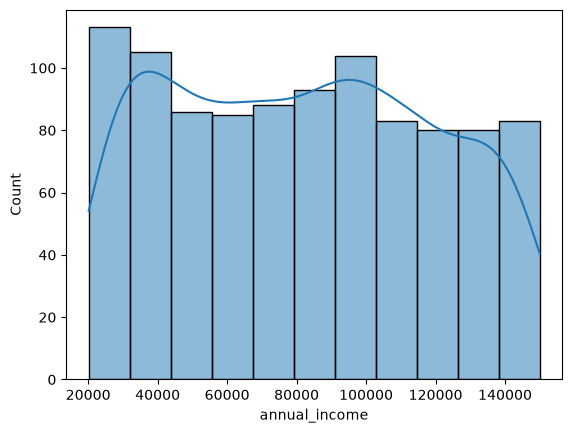

In [15]:
sns.histplot(data=df, x="annual_income", kde=True)
plt.show()


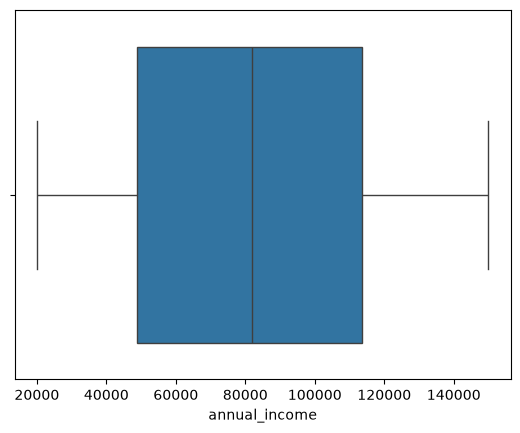

In [16]:
sns.boxplot(data=df, x="annual_income")
plt.show()

In [17]:
df["loan_approved"].value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

In [18]:
df["applicant_id"].nunique()

1000

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
# for col in df.columns:
#     print("\n",col) 
#     print(df[col].unique()) 

# instead of getting unique values of each variable we will do 

df["employment_status"].unique()

array(['Unemployed', 'Employed', 'Self-employed'], dtype=object)

In [21]:
df["gender"].unique()


array(['Male', 'Female'], dtype=object)

In [22]:
df["marital_status"].unique()

array(['Divorced', 'Married', 'Single'], dtype=object)

In [23]:
df.nunique()

applicant_id            1000
age                       44
gender                     2
marital_status             3
annual_income            996
loan_amount              990
credit_score             452
num_dependents             5
existing_loans_count       5
employment_status          3
loan_approved              2
dtype: int64

In [24]:
df["loan_approved"].value_counts(normalize=True)

loan_approved
1    0.729
0    0.271
Name: proportion, dtype: float64

In [25]:
df["loan_approved"].value_counts(normalize=True)*100

loan_approved
1    72.9
0    27.1
Name: proportion, dtype: float64

# EDA 

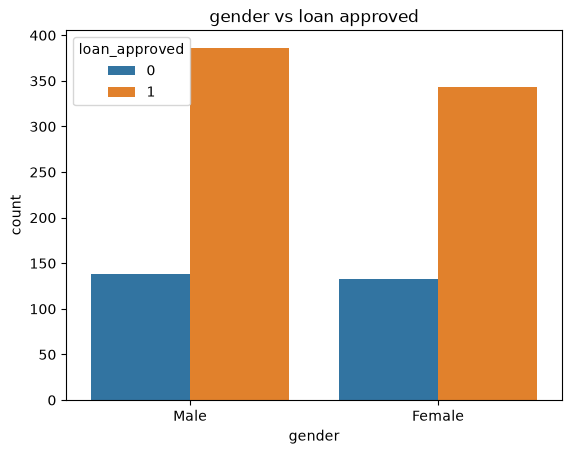

In [26]:
sns.countplot(data=df,x="gender",hue="loan_approved")
plt.title("gender vs loan approved")
plt.show()

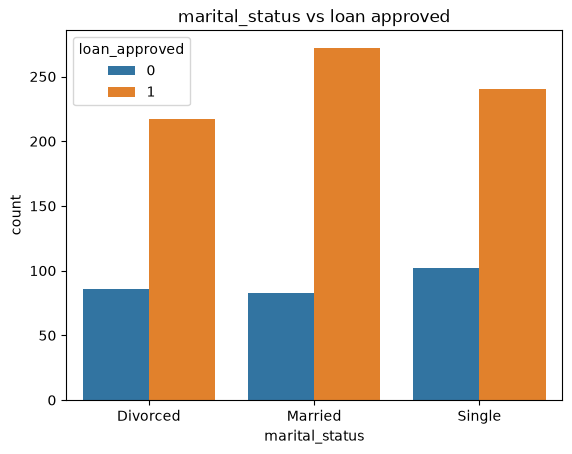

In [27]:
sns.countplot(data=df,x="marital_status",hue="loan_approved")
plt.title("marital_status vs loan approved")
plt.show()

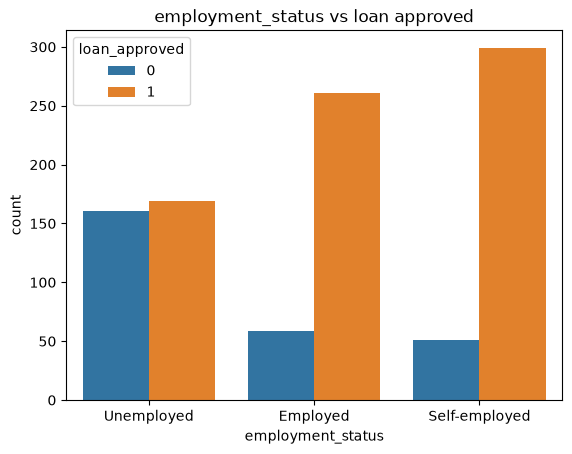

In [28]:
sns.countplot(data=df,x="employment_status",hue="loan_approved")
plt.title("employment_status vs loan approved")
plt.show()

In [29]:
# from this we can see that unemployed has less chance of loan approval

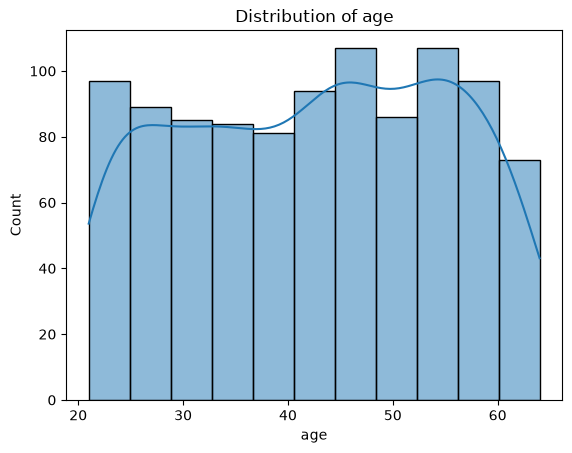

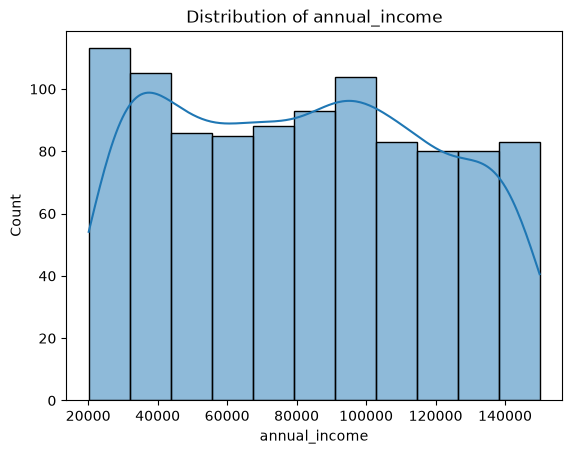

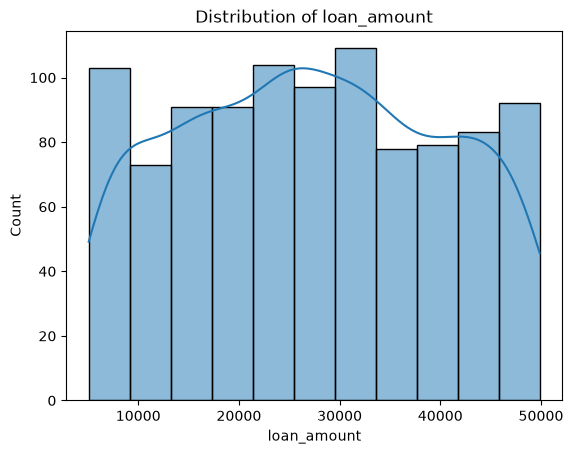

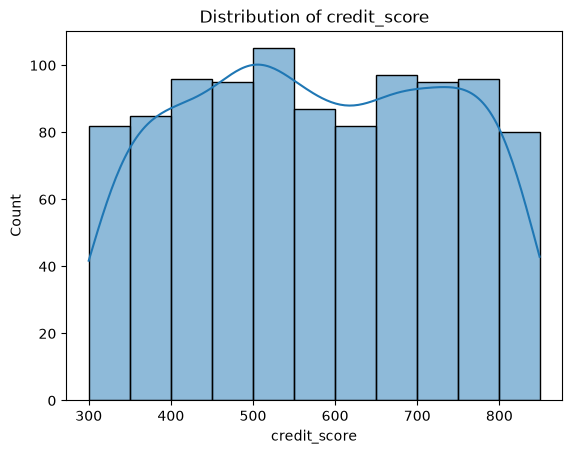

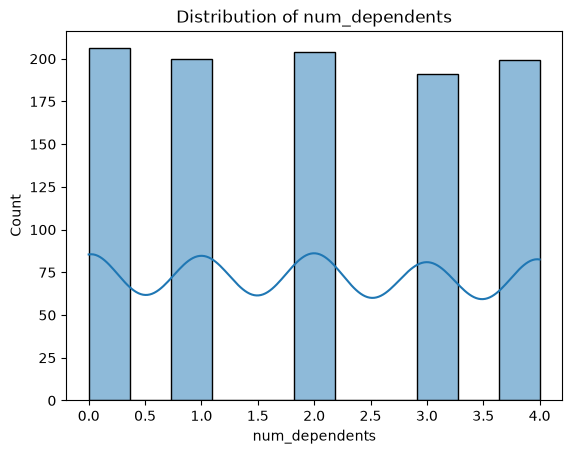

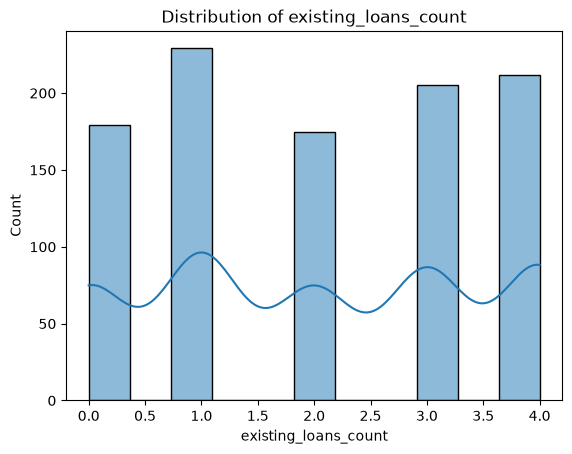

In [30]:
# for numerical columns we will use histogram 
num_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

for col in num_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

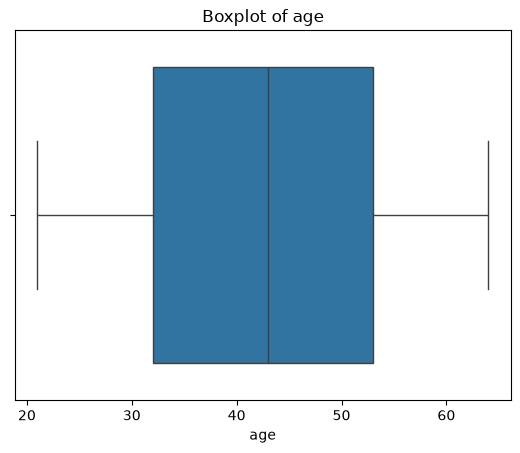

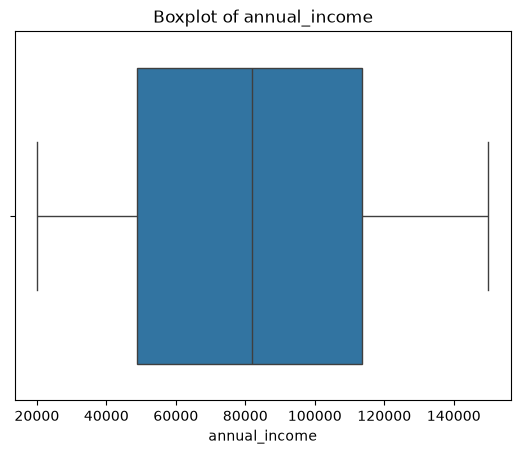

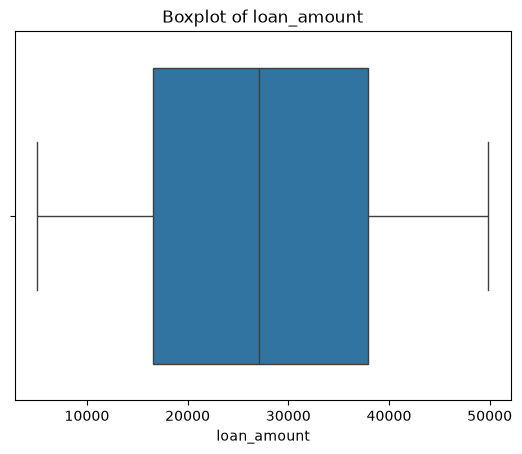

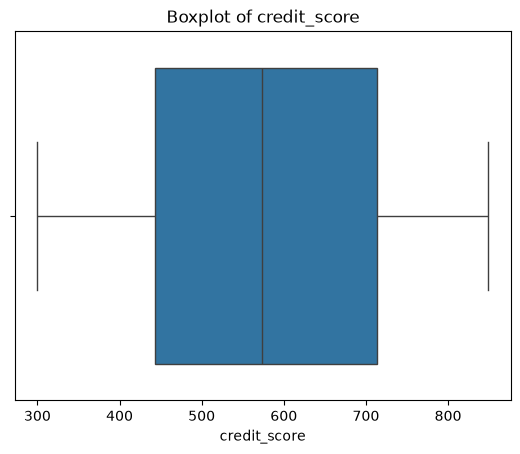

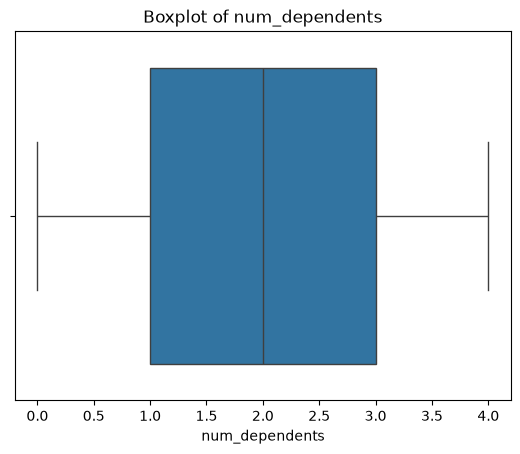

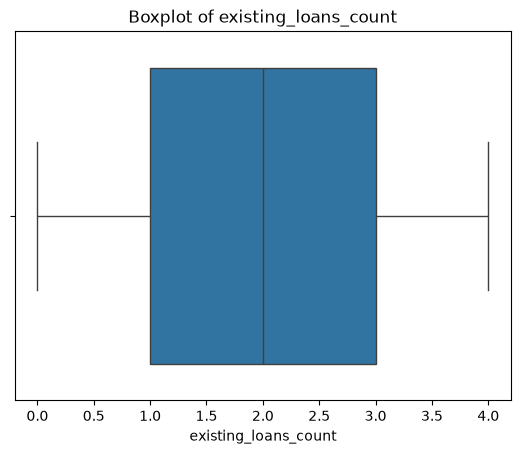

In [31]:
for col in num_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [32]:
# most important EDA: numerical features vs target

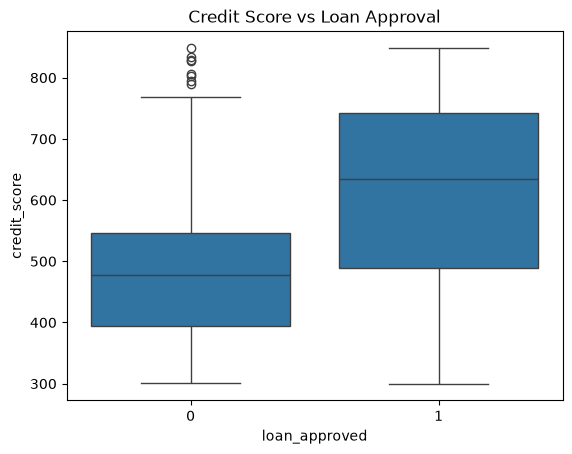

In [33]:
sns.boxplot(data=df, x="loan_approved", y="credit_score")
plt.title("Credit Score vs Loan Approval")
plt.show()

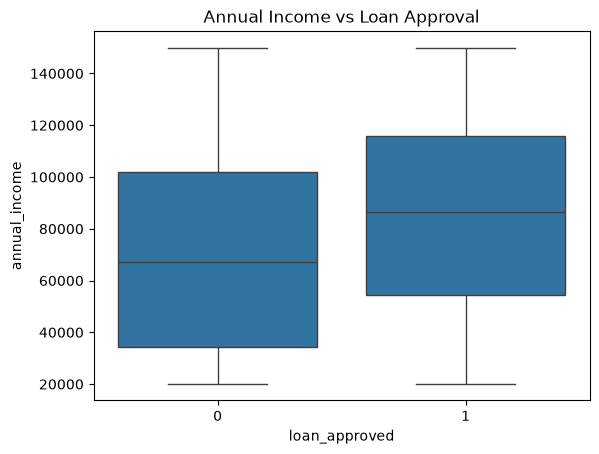

In [34]:
sns.boxplot(data=df, x="loan_approved", y="annual_income")
plt.title("Annual Income vs Loan Approval")
plt.show()

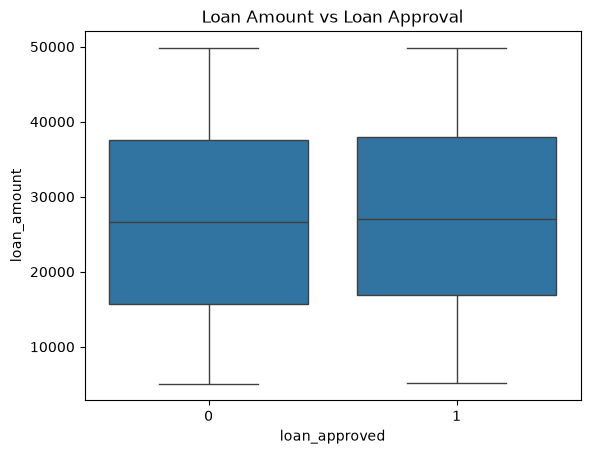

In [35]:
sns.boxplot(data=df, x="loan_approved", y="loan_amount")
plt.title("Loan Amount vs Loan Approval")
plt.show()

In [36]:
# now for categorical variables 

pd.crosstab(
    df["employment_status"],
    df["loan_approved"],
    normalize="index"
) * 100

loan_approved,0,1
employment_status,,
Employed,18.437500,81.562500
Self-employed,14.571429,85.428571
Unemployed,48.787879,51.212121


In [37]:
pd.crosstab(
    df["gender"],
    df["loan_approved"],
    normalize="index"
) * 100

loan_approved,0,1
gender,,
Female,27.941176,72.058824
Male,26.335878,73.664122


In [38]:
pd.crosstab(
    df["marital_status"],
    df["loan_approved"],
    normalize="index"
) * 100

loan_approved,0,1
marital_status,,
Divorced,28.382838,71.617162
Married,23.380282,76.619718
Single,29.824561,70.175439


In [39]:
# Checking correlation 

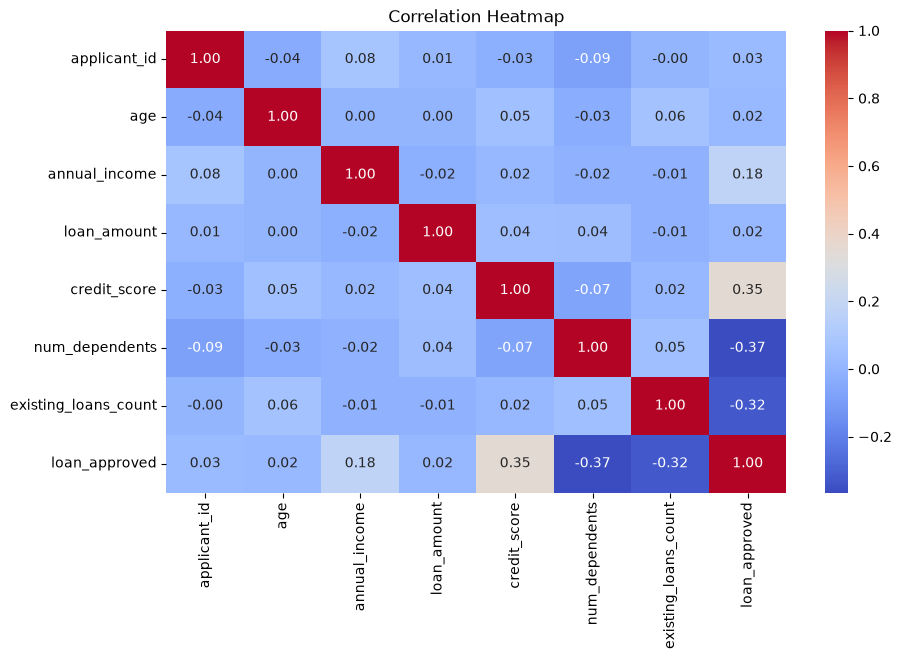

In [40]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

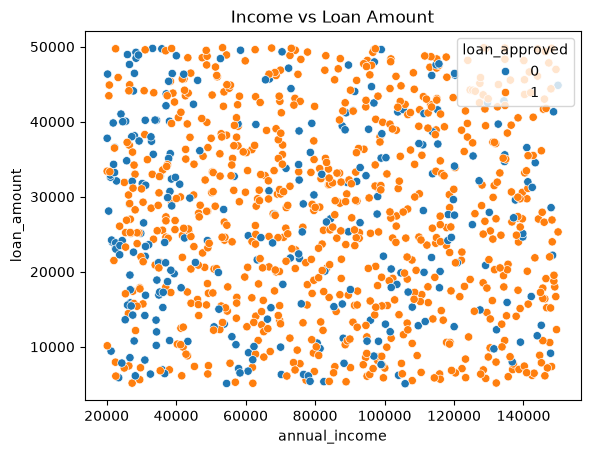

In [41]:
sns.scatterplot(
    data=df,
    x="annual_income",
    y="loan_amount",
    hue="loan_approved"
)

plt.title("Income vs Loan Amount")
plt.show()

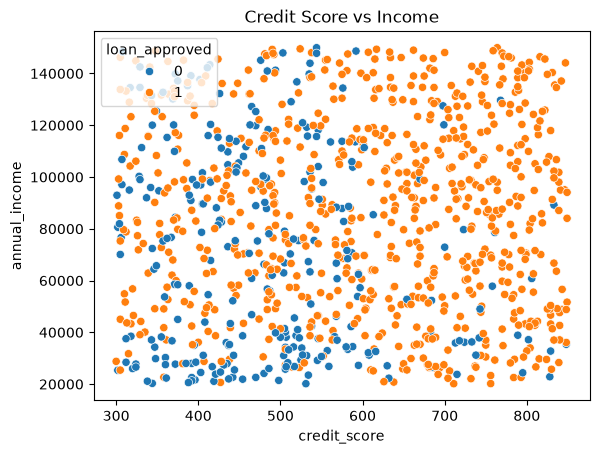

In [42]:
sns.scatterplot(
    data=df,
    x="credit_score",
    y="annual_income",
    hue="loan_approved"
)

plt.title("Credit Score vs Income")
plt.show()

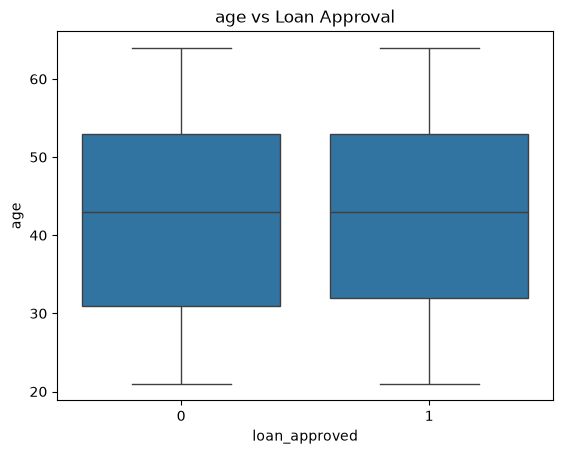

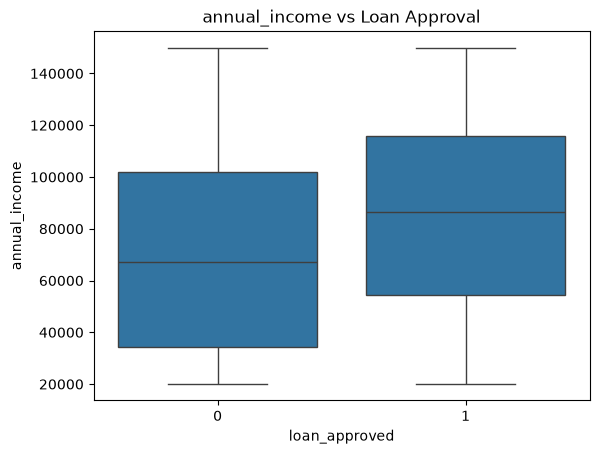

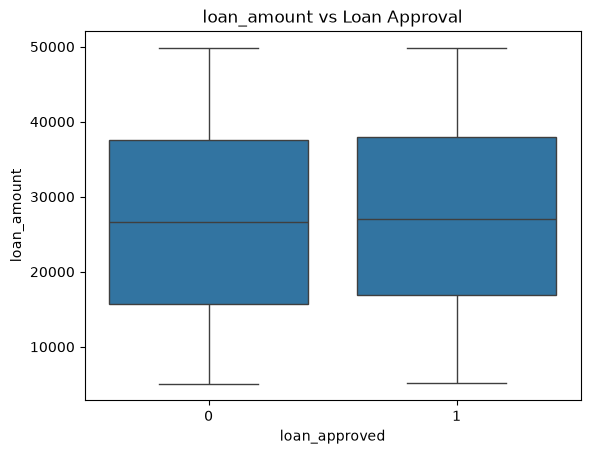

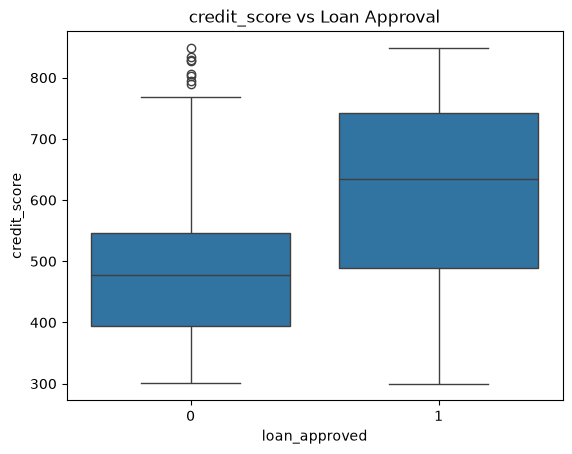

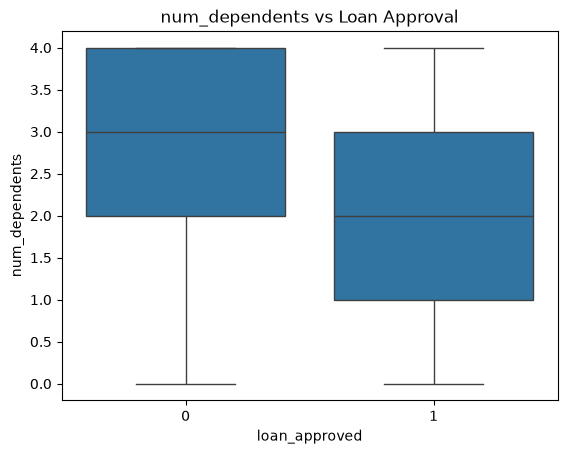

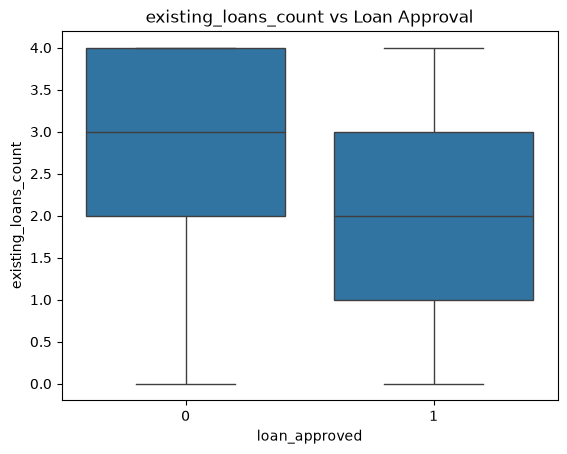

In [43]:
# Numerical features vs loan approval

num_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

for col in num_cols:
    sns.boxplot(data=df, x="loan_approved", y=col)
    plt.title(f"{col} vs Loan Approval")
    plt.show()

In [44]:
# Calculating the group average 
df.groupby("loan_approved")[num_cols].mean()


,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count
loan_approved,,,,,,
0,42.081181,71111.959410,26922.099631,486.365314,2.826568,2.793358
1,42.676269,86010.467764,27364.851852,609.492455,1.661180,1.762689


In [45]:
df.groupby("loan_approved")[num_cols].median()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count
loan_approved,,,,,,
0,43.0,67299.0,26642.0,477.0,3.0,3.0
1,43.0,86314.0,27056.0,635.0,2.0,2.0


<Axes: xlabel='gender', ylabel='count'>

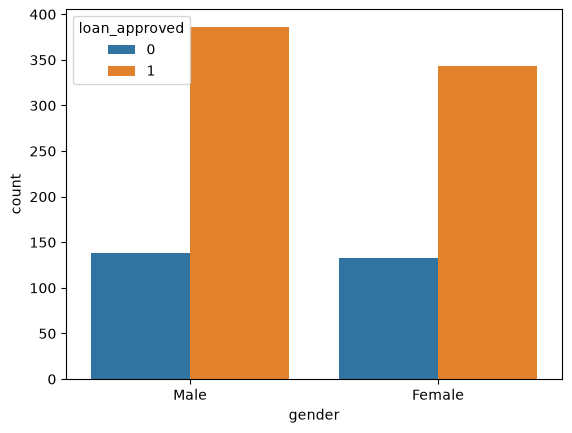

In [46]:
sns.countplot(data=df, x="gender", hue="loan_approved")

In [47]:
for col in ["gender", "marital_status", "employment_status"]:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df["loan_approved"],
            normalize="index"
        ) * 100
    )


gender
loan_approved          0          1
gender                             
Female         27.941176  72.058824
Male           26.335878  73.664122

marital_status
loan_approved           0          1
marital_status                      
Divorced        28.382838  71.617162
Married         23.380282  76.619718
Single          29.824561  70.175439

employment_status
loan_approved              0          1
employment_status                      
Employed           18.437500  81.562500
Self-employed      14.571429  85.428571
Unemployed         48.787879  51.212121


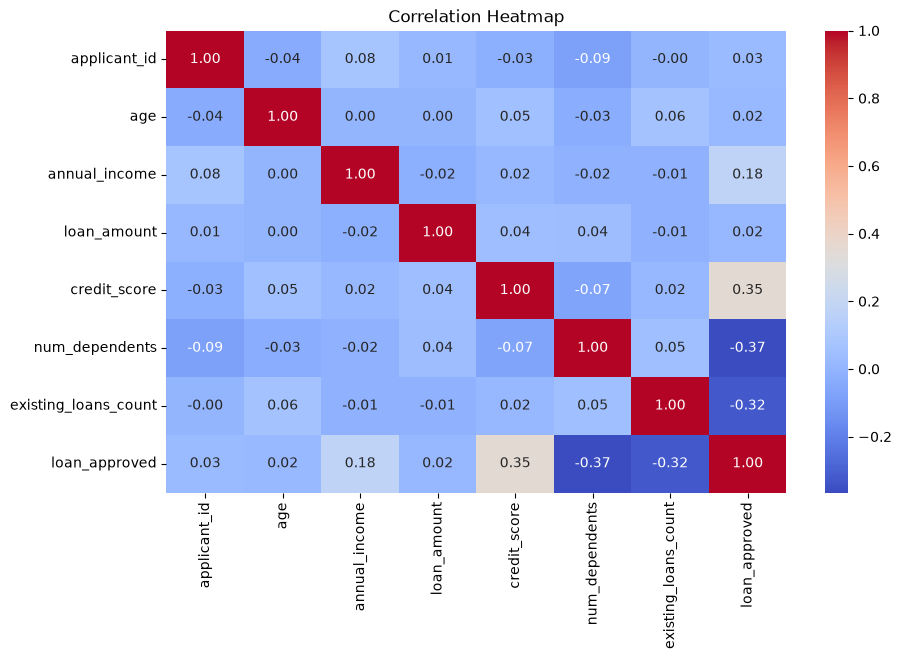

In [48]:
plt.figure(figsize=(10, 6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [49]:
X = df.drop(columns=["loan_approved", "applicant_id"])
y = df["loan_approved"]

In [50]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['age', 'gender', 'marital_status', 'annual_income', 'loan_amount',
       'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status'],
      dtype='object')

Target:
loan_approved


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 9)
X_test: (200, 9)
y_train: (800,)
y_test: (200,)


In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(800, 9)
(200, 9)
loan_approved
1    0.72875
0    0.27125
Name: proportion, dtype: float64
loan_approved
1    0.73
0    0.27
Name: proportion, dtype: float64


In [54]:
categorical_cols = [
    "gender",
    "marital_status",
    "employment_status"
]

categorical_cols

['gender', 'marital_status', 'employment_status']

In [55]:
numerical_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

In [56]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", drop="first")

In [57]:
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [58]:
print("Encoded training shape:", X_train_cat.shape)
print("Encoded testing shape:", X_test_cat.shape)

Encoded training shape: (800, 5)
Encoded testing shape: (200, 5)


In [59]:
print(encoder.get_feature_names_out(categorical_cols))

['gender_Male' 'marital_status_Married' 'marital_status_Single'
 'employment_status_Self-employed' 'employment_status_Unemployed']


In [60]:
numerical_cols = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

In [62]:
print("Scaled training shape:", X_train_num.shape)
print("Scaled testing shape:", X_test_num.shape)

Scaled training shape: (800, 6)
Scaled testing shape: (200, 6)


In [63]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num, X_train_cat])
X_test_final = hstack([X_test_num, X_test_cat])

In [64]:
print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (800, 11)
Final testing shape: (200, 11)


In [65]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

In [66]:
logistic_model.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [67]:
y_pred = logistic_model.predict(X_test_final)

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.89


In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 37  17]
 [  5 141]]


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.69      0.77        54
           1       0.89      0.97      0.93       146

    accuracy                           0.89       200
   macro avg       0.89      0.83      0.85       200
weighted avg       0.89      0.89      0.89       200



In [71]:
from sklearn.metrics import roc_auc_score

y_prob = logistic_model.predict_proba(X_test_final)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9493911719939117


# Decision tree 

In [72]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [73]:
decision_tree.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [74]:
y_pred_tree = decision_tree.predict(X_test_final)

In [75]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print()
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.99

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
           1       0.99      1.00      0.99       146

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



In [76]:
y_prob_tree = decision_tree.predict_proba(X_test_final)[:, 1]

tree_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree ROC-AUC:", tree_auc)

Decision Tree ROC-AUC: 0.9814814814814815


In [77]:
# validating the results of decision tree 

In [78]:
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

Tree depth: 5
Number of leaves: 20


In [79]:
y_train_pred_tree = decision_tree.predict(X_train_final)

train_accuracy_tree = accuracy_score(y_train, y_train_pred_tree)

print("Training Accuracy:", train_accuracy_tree)
print("Testing Accuracy:", tree_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.99


# Random Forest 

In [80]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [81]:
random_forest.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [82]:
y_pred_rf = random_forest.predict(X_test_final)

In [83]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.98

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.97      1.00      0.99       146

    accuracy                           0.98       200
   macro avg       0.99      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



In [84]:
y_prob_rf = random_forest.predict_proba(X_test_final)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9982242516489093


In [85]:
# Comparing all three models 
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "ROC-AUC": [
        auc,
        tree_auc,
        rf_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.89,0.949391
1,Decision Tree,0.99,0.981481
2,Random Forest,0.98,0.998224


In [86]:
y_train_pred_rf = random_forest.predict(X_train_final)

rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Testing Accuracy:", rf_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.98


In [87]:
print("Accuracy gap:", rf_train_accuracy - rf_accuracy)

Accuracy gap: 0.020000000000000018


# Hyperparameter tuning 

In [88]:
# using grid search cv 
from sklearn.model_selection import GridSearchCV

In [89]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [90]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [91]:
rf_grid.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ve

In [92]:
print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_grid.best_score_)

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV ROC-AUC:
0.9974234121487531


In [93]:
best_rf = rf_grid.best_estimator_

In [94]:
y_pred_best_rf = best_rf.predict(X_test_final)

In [95]:
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Accuracy:", best_rf_accuracy)
print()
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.96

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        54
           1       0.95      1.00      0.97       146

    accuracy                           0.96       200
   macro avg       0.97      0.93      0.95       200
weighted avg       0.96      0.96      0.96       200



In [96]:
y_prob_best_rf = best_rf.predict_proba(X_test_final)[:, 1]

best_rf_auc = roc_auc_score(y_test, y_prob_best_rf)

print("Tuned Random Forest ROC-AUC:", best_rf_auc)

Tuned Random Forest ROC-AUC: 0.9987316083206494


In [97]:
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

print(cm_best_rf)

[[ 46   8]
 [  0 146]]


In [98]:
# best model so far by ROC-AUC is the tuned Random Forest:

# Accuracy: 96%
# ROC-AUC: 0.9987
# False negatives: 0
# Model: best_rf

In [99]:
import joblib

artifacts = {
    "model": best_rf,
    "encoder": encoder,
    "scaler": scaler,
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols
}

joblib.dump(artifacts, "loan_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
